# Testing MG-cs2

In this notebook, I test a novel scenario in which the dark energy sound speed sources the braiding function $\alpha_B$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb

In [16]:
def get_camb_solution(alpha_K_0, cs2, omega_m, w0, wa, use_cs2):
    ombh2 = 0.0122
    h = 0.7
    omch2 = (omega_m - ombh2/h**2)*h**2
    cosmo = camb.set_params(
        H0=100*h, ombh2=ombh2, omch2=omch2, As=2.1e-9, ns=0.96, tau=0.06,
        num_nu_massless=3.044, omnuh2=0, WantTransfer=True, w=w0, wa=wa,
        dark_energy_model="fluid" if (1+w0)*(1+w0+wa) > 0 else "ppf",
        cs2_0=cs2, use_cs2=use_cs2, alpha_K_0=alpha_K_0, alpha_K_parametrization=2
    )
    cosmo.set_matter_power(redshifts=(0,), kmax=3)
    results = camb.get_background(cosmo)
    cl_tt = results.get_cmb_power_spectra(cosmo, CMB_unit="muK")["total"][:, 0]
    kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints=200)
    log_a = results.Params.log_a
    alpha_B = results.Params.alpha_B
    alpha_K = results.Params.alpha_K
    mu = results.Params.mu
    return log_a*np.log10(np.e), alpha_B, alpha_K, mu, kh, z, pk, cl_tt

Text(0, 0.5, '$C_\\ell^{TT}$')

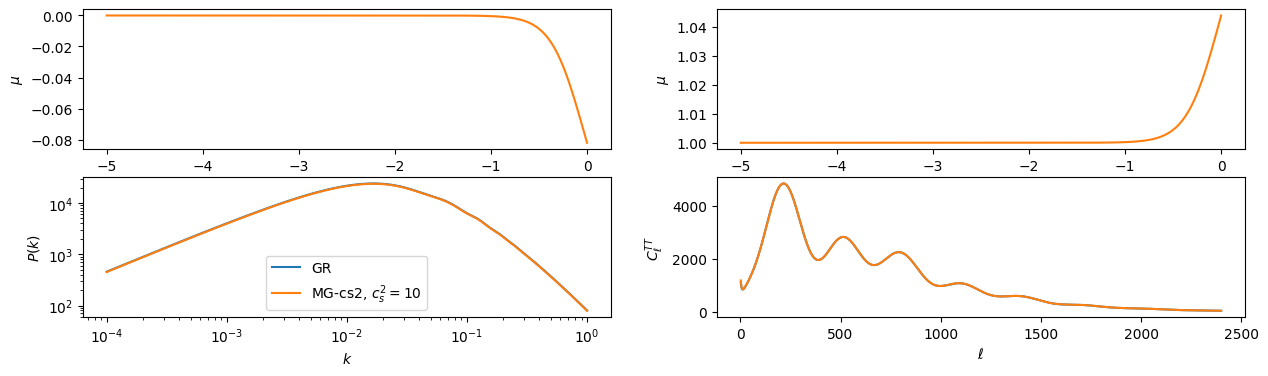

In [17]:
log_a, alpha_B, alpha_K, mu, kh, z, pk_mg, cl_tt_mg = get_camb_solution(alpha_K_0=1, cs2=1, omega_m=0.3, w0=-0.9, wa=0, use_cs2=True)
_, _, _, _, kh, z, pk_gr, cl_tt_gr            = get_camb_solution(alpha_K_0=1, cs2=1, omega_m=0.3, w0=-0.9, wa=0, use_cs2=False)
ell = np.arange(len(cl_tt_gr))

fig, axs = plt.subplots(2, 2, figsize=(15, 4))

axs[0,0].plot(log_a, alpha_B, color="tab:orange")
axs[0,0].set_xlabel("$\\log(a)$")
axs[0,0].set_ylabel("$\\mu$")

axs[0,1].plot(log_a, mu, color="tab:orange")
axs[0,1].set_xlabel("$\\log(a)$")
axs[0,1].set_ylabel("$\\mu$")

axs[1,0].loglog(kh, pk_gr[0], label="GR")
axs[1,0].loglog(kh, pk_mg[0], label="MG-cs2, $c_s^2 = 10$")
axs[1,0].set_xlabel("$k$")
axs[1,0].set_ylabel("$P(k)$")
axs[1,0].legend()

axs[1,1].plot(ell[2:], cl_tt_gr[2:])
axs[1,1].plot(ell[2:], cl_tt_mg[2:])
axs[1,1].set_xlabel("$\\ell$")
axs[1,1].set_ylabel("$C_\\ell^{TT}$")

In [18]:
np.array(alpha_K)

array([2.21353704e-16, 2.21353704e-16, 2.73700898e-16, 3.38392694e-16,
       4.18329580e-16, 5.17090318e-16, 6.39089568e-16, 7.89771875e-16,
       9.75850275e-16, 1.20559971e-15, 1.48921764e-15, 1.83926719e-15,
       2.27122122e-15, 2.80413035e-15, 3.46144245e-15, 4.27200760e-15,
       5.27130989e-15, 6.50297627e-15, 8.02062378e-15, 9.89011971e-15,
       1.21923452e-14, 1.50265724e-14, 1.85145880e-14, 2.28057253e-14,
       2.80830005e-14, 3.45705887e-14, 4.25429259e-14, 5.23357821e-14,
       6.43597196e-14, 7.91164375e-14, 9.72186020e-14, 1.19413887e-13,
       1.46614085e-13, 1.79930337e-13, 2.20715704e-13, 2.70616585e-13,
       3.31634732e-13, 4.06201984e-13, 4.97270231e-13, 6.08419591e-13,
       7.43988354e-13, 9.09228909e-13, 1.11049463e-12, 1.35546366e-12,
       1.65340653e-12, 2.01550598e-12, 2.45523856e-12, 2.98882971e-12,
       3.63579574e-12, 4.41958866e-12, 5.36836283e-12, 6.51588526e-12,
       7.90261574e-12, 9.57698721e-12, 1.15969223e-11, 1.40316279e-11,
      